# KNN

In [7]:
from datetime import datetime
from nltk.tokenize import sent_tokenize
from nltk.tokenize import word_tokenize
from scipy.sparse import load_npz, hstack
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_score,
    recall_score,
    RocCurveDisplay
)
from sklearn.model_selection import cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import nltk
import numpy as np
import optuna
import pandas as pd

Se carga dataset.

In [8]:
X_train = load_npz('datasets/X_train.npz')
X_test = load_npz('datasets/X_test.npz')
y_train = pd.read_csv('datasets/y_train.csv')['label']
y_test = pd.read_csv('datasets/y_test.csv')['label']

Se agregan los tres features más significativos recomendados en la bibliografía útiles para este tipo de algoritmos; se sugieren muchos más, pero también se sugiere que se use la menor cantidad de features extra para alcanzar la mejor eficiencia del modelo.

In [9]:
X_extra_train = pd.read_csv('datasets/X_extra_train.csv')
X_extra_test = pd.read_csv('datasets/X_extra_test.csv')

### Cantidad de verbos imperativos
Cuenta la presencia de verbos directivos o de mando en el correo electrónico. En la bibliografía, los verbos específicos considerados son "click", "verify",
"submit", "download" y "update").

In [11]:
IMPERATIVE_VERBS = ['click', 'verify', 'submit', 'download', 'update']

def get_imperative_verb_count(text):
    return sum(text.lower().count(verb) for verb in IMPERATIVE_VERBS)

X_extra_train['imperative_verbs_count'] = X_extra_train['remainder__Email Text Raw'].apply(get_imperative_verb_count)
X_extra_test['imperative_verbs_count'] = X_extra_test['remainder__Email Text Raw'].apply(get_imperative_verb_count)

### Complejidad en oraciones
Considera el número de conectores por oración. Se divide por el número total de oraciones, lo que permite medir cuántas oraciones subordinadas pueden aparecer en todo el texto.

In [12]:
LINKING_WORDS = ['and', 'but', 'or', 'because']

nltk.data.path.append('nltk_data')
nltk.download('punkt_tab', 'nltk_data')

def get_clause_density(text):
    sentence_count = len(sent_tokenize(text))
    if sentence_count == 0:
        return 0.0
    total_conjunctions = sum(text.lower().count(word) for word in LINKING_WORDS)
    complexity_ratio = total_conjunctions / sentence_count
    return complexity_ratio / sentence_count

X_extra_train['clause_density'] = X_extra_train['remainder__Email Text Raw'].apply(get_clause_density)
X_extra_test['clause_density'] = X_extra_test['remainder__Email Text Raw'].apply(get_clause_density)

[nltk_data] Downloading package punkt_tab to nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


### Densidad de pronombres
Divide el número total de pronombres entre el número total de palabras.

In [13]:
TARGET_PRONOUNS = ['i', 'you', 'he', 'she', 'it', 'we', 'they']

def get_pronoun_density(text):
    tokens = word_tokenize(text.lower())
    total_words = len(tokens)
    if total_words == 0:
        return 0.0
    pronoun_count = sum(1 for word in tokens if word in TARGET_PRONOUNS)
    return pronoun_count / total_words

X_extra_train['pronoun_density'] = X_extra_train['remainder__Email Text Raw'].apply(get_pronoun_density)
X_extra_test['pronoun_density'] = X_extra_test['remainder__Email Text Raw'].apply(get_pronoun_density)

KNN requiere valores estandarizados.

In [14]:
extra_cols = ['imperative_verbs_count', 'clause_density', 'pronoun_density']

X_train = hstack([X_train, X_extra_train[extra_cols].values])
X_test = hstack([X_test, X_extra_test[extra_cols].values])

scaler = StandardScaler(with_mean=False)

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Se inicializa KNN con _k = 5_ y se prueba.

In [15]:
knn_model = KNeighborsClassifier(n_neighbors=5)

start_train_time = datetime.now()
knn_model.fit(X_train_scaled, y_train)
end_train_time = datetime.now()

train_duration = end_train_time - start_train_time

start_predict_duration = datetime.now()
y_pred = knn_model.predict(X_test_scaled)
end_predict_duration = datetime.now()

predict_duration = end_predict_duration - start_predict_duration

#### Métricas

Se evalúa.

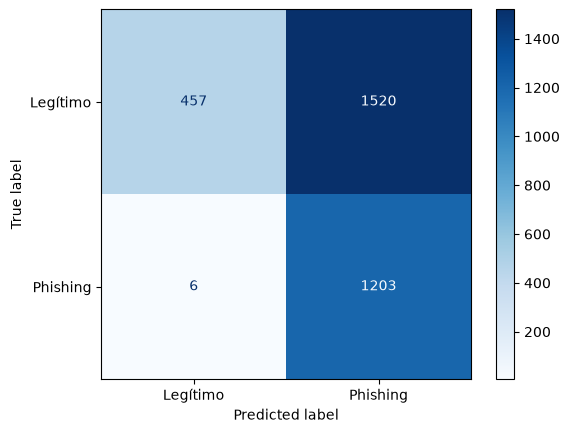

In [16]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=['Legítimo', 'Phishing'], cmap='Blues')

In [17]:
cm_knn = confusion_matrix(y_test, y_pred)
P = cm_knn[1, :].sum()
N = cm_knn[0, :].sum()
TP = cm_knn[1, 1]
TN = cm_knn[0, 0]

TPR_knn = TP / P
TNR_knn = TN / N
balanced_accuracy_knn = (TPR_knn + TNR_knn) / 2

precision_knn = precision_score(y_test, y_pred, zero_division=0)
recall_knn = recall_score(y_test, y_pred, zero_division=0)
f1_knn = f1_score(y_test, y_pred, zero_division=0)

print(f"Exactitud balanceada:    {balanced_accuracy_knn:.4f}")
print(f"Precisión:               {precision_knn:.4f}")
print(f"Sensibilidad (Recall):   {TPR_knn:.4f}")
print(f"F1-score:                {f1_knn:.4f}")
print(f"Especificidad:           {TNR_knn:.4f}")
print(f"Recuperación (Recall):   {recall_knn:.4f}")
print(f"Tiempo de entrenamiento: {train_duration}")
print(f"Tiempo de predicción:    {predict_duration}")

Exactitud balanceada:    0.6131
Precisión:               0.4418
Sensibilidad (Recall):   0.9950
F1-score:                0.6119
Especificidad:           0.2312
Recuperación (Recall):   0.9950
Tiempo de entrenamiento: 0:00:00.014070
Tiempo de predicción:    0:00:01.891485


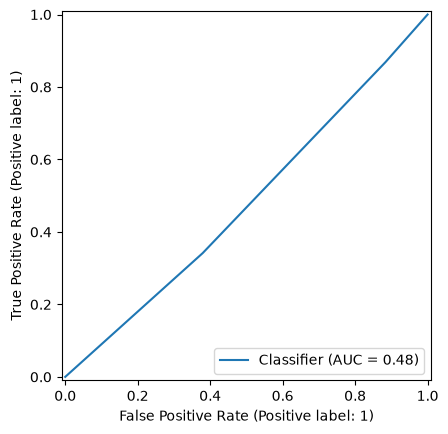

In [18]:
y_scores = knn_model.predict_proba(X_test)[:, 1]

RocCurveDisplay.from_predictions(y_test, y_scores)

Está adivinando. Es un desastre.

## Optimización de parámetros

Se define la función objetivo y se prepara el estudio.

In [19]:
def objective(trial):
    n_neighbors = trial.suggest_int("n_neighbors", 1, 50)
    weights = trial.suggest_categorical("weights", ["uniform", "distance"])
    metric = trial.suggest_categorical("metric", ["euclidean", "manhattan", "cosine"])

    model = KNeighborsClassifier(n_neighbors=n_neighbors, weights=weights, metric=metric)

    score = cross_val_score(model, X_train_scaled, y_train, cv=3, scoring='f1', n_jobs=-1)
    return score.mean()

def champion_callback(study, frozen_trial):
    winner = study.user_attrs.get("winner", None)

    if study.best_value and winner != study.best_value:
        study.set_user_attr("winner", study.best_value)
        if winner:
            improvement_percent = (abs(winner - study.best_value) / study.best_value)
            improvement_percent *= 100
            print(
                f"Trial {frozen_trial.number} achieved value: {frozen_trial.value} "
                f"with {improvement_percent: .4f}% improvement"
            )
        else:
            print(f"Initial trial {frozen_trial.number} achieved value: " 
            f"{frozen_trial.value}")

optuna.logging.set_verbosity(optuna.logging.ERROR)

Se ejecutan 100 trials.

In [20]:
study = optuna.create_study(direction="maximize", pruner=optuna.pruners.HyperbandPruner)
start_train_time_opt = datetime.now()
study.optimize(objective, n_trials=100, callbacks=[champion_callback], n_jobs=-1)
end_train_time_opt = datetime.now()

train_duration_opt = end_train_time_opt - start_train_time_opt

Initial trial 1 achieved value: 0.9044301439002345
Trial 3 achieved value: 0.9059027389421916 with  0.1626% improvement
Trial 6 achieved value: 0.9072497730179969 with  0.1485% improvement
Trial 9 achieved value: 0.9162038361244415 with  0.9773% improvement
Trial 11 achieved value: 0.917631694532798 with  0.1556% improvement
Trial 68 achieved value: 0.918275675400673 with  0.0701% improvement


In [21]:
best_params = study.best_params
best_params

{'n_neighbors': 48, 'weights': 'distance', 'metric': 'cosine'}

Se entrena el modelo con los parámetros resultantes de la optimización.

In [22]:
optimized_knn_model = KNeighborsClassifier(**best_params)

start_train_time_opt = datetime.now()
optimized_knn_model.fit(X_train_scaled, y_train)
end_train_time_opt = datetime.now()

train_duration_opt = train_duration_opt + (end_train_time_opt - start_train_time_opt)

start_predict_duration_opt = datetime.now()
y_pred = optimized_knn_model.predict(X_test_scaled)
end_predict_duration_opt = datetime.now()

predict_duration_opt = end_predict_duration_opt - start_predict_duration_opt

#### Métricas

Se evalúa.

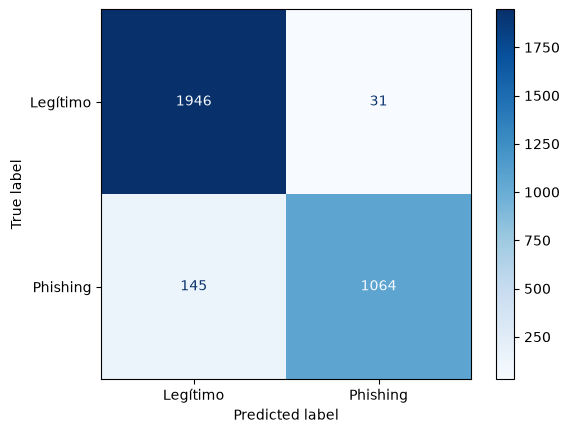

In [23]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=['Legítimo', 'Phishing'], cmap='Blues')

In [24]:
cm_optimized_knn = confusion_matrix(y_test, y_pred)
P_opt = cm_optimized_knn[1, :].sum()
N_opt = cm_optimized_knn[0, :].sum()
TP_opt = cm_optimized_knn[1, 1]
TN_opt = cm_optimized_knn[0, 0]

TPR_knn_opt = TP_opt / P_opt
TNR_knn_opt = TN_opt / N_opt
balanced_accuracy_knn_opt = (TPR_knn_opt + TNR_knn_opt) / 2

precision_knn_opt = precision_score(y_test, y_pred, zero_division=0)
recall_knn_opt = recall_score(y_test, y_pred, zero_division=0)
f1_knn_opt = f1_score(y_test, y_pred, zero_division=0)

print("                         Antes           Después")
print(f"Exactitud balanceada:    {balanced_accuracy_knn:.4f}          {balanced_accuracy_knn_opt:.4f}")
print(f"Precisión:               {precision_knn:.4f}          {precision_knn_opt:.4f}")
print(f"Sensibilidad (Recall):   {TPR_knn:.4f}          {TPR_knn_opt:.4f}")
print(f"F1-score:                {f1_knn:.4f}          {f1_knn_opt:.4f}")
print(f"Especificidad:           {TNR_knn:.4f}          {TNR_knn_opt:.4f}")
print(f"Recuperación (Recall):   {recall_knn:.4f}          {recall_knn_opt:.4f}")
print(f"Tiempo de entrenamiento: {train_duration}  {train_duration_opt}")
print(f"Tiempo de predicción:    {predict_duration}  {predict_duration_opt}")

                         Antes           Después
Exactitud balanceada:    0.6131          0.9322
Precisión:               0.4418          0.9717
Sensibilidad (Recall):   0.9950          0.8801
F1-score:                0.6119          0.9236
Especificidad:           0.2312          0.9843
Recuperación (Recall):   0.9950          0.8801
Tiempo de entrenamiento: 0:00:00.014070  0:05:37.823991
Tiempo de predicción:    0:00:01.891485  0:00:02.519825


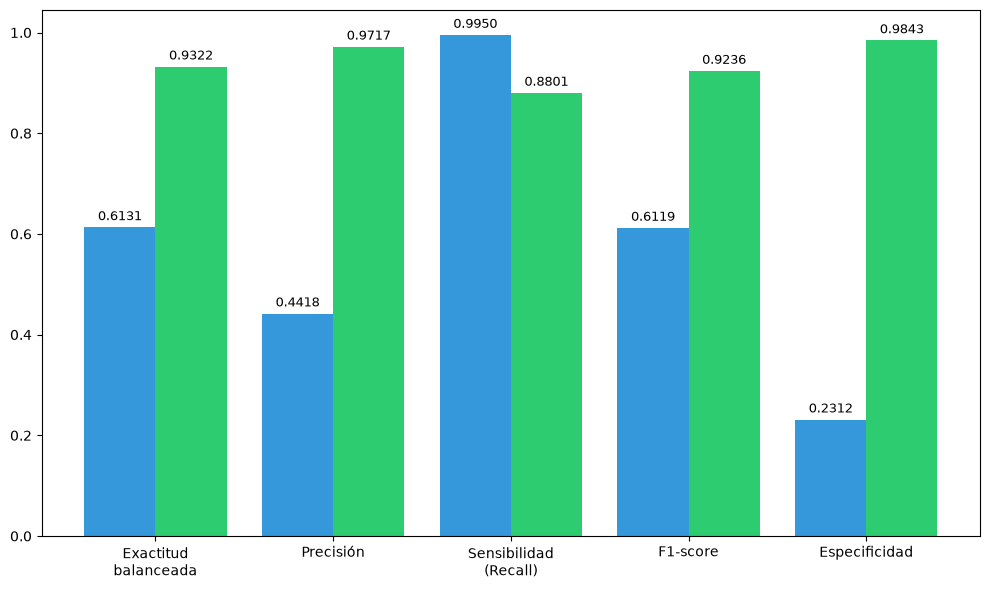

In [25]:
metrics_names = [
    'Exactitud\nbalanceada', 
    'Precisión', 
    'Sensibilidad\n(Recall)', 
    'F1-score', 
    'Especificidad'
]

before_vals = [
    balanced_accuracy_knn, 
    precision_knn, 
    TPR_knn, 
    f1_knn, 
    TNR_knn
]

after_vals = [
    balanced_accuracy_knn_opt, 
    precision_knn_opt, 
    TPR_knn_opt, 
    f1_knn_opt, 
    TNR_knn_opt
]

x = np.arange(5)

fig, ax = plt.subplots(figsize=(10, 6))

rects1 = ax.bar(x - 0.2, before_vals, 0.4, color='#3498db')
for rect in rects1:
    height = rect.get_height()
    ax.annotate(f'{height:.4f}',
                xy=(rect.get_x() + rect.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom', fontsize=9)
rects2 = ax.bar(x + 0.2, after_vals, 0.4, color='#2ecc71')
for rect in rects2:
    height = rect.get_height()
    ax.annotate(f'{height:.4f}',
                xy=(rect.get_x() + rect.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(metrics_names, fontsize=10)

plt.tight_layout()
plt.show()


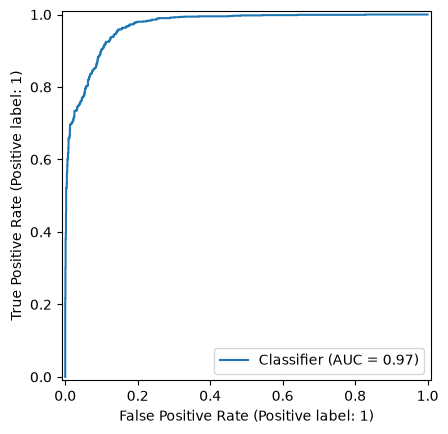

In [26]:
y_scores = optimized_knn_model.predict_proba(X_test)[:, 1]

RocCurveDisplay.from_predictions(y_test, y_scores)

Funcionó.